# Observable → f_b — **Y_SZ (+ kSZ) edition with a realistic forward model**

**⚠️ Provisional.** Same caveats as `profile_fb_map.ipynb` and `profile_fb_realdata.ipynb`:
single subgrid model (CAMELS IllustrisTNG), fixed cosmology, projected stacks, emulator-painted training data.
This notebook is **deliberately narrower in observables and broader in observational realism**.

### Why a third notebook
Reading the previous two as an observational astronomer, two of the next steps were
actionable now and the rest are out of scope (off-grid suites, cosmology+z marginalisation,
real-data demo). The two we address here:

1. **Replace the X-ray proxy.** `S_X = Gas²·√T` had no cooling function, no metallicity,
   no band response. Rather than build a defensible APEC-based S_X, we **drop X-ray entirely**
   and restrict ourselves to two observables that *are* measured cleanly today on stacked clusters:
   - **Y_SZ(r)** — the stacked Compton-y profile (ACT, Planck; same definition as before).
   - **kSZ(r)** — a stacked optical-depth profile, proportional to gas surface density
     `τ_e(r) = σ_T ∫ n_e dl ∝ Σ_gas(r)`. The pairwise/velocity-weighted kSZ stack measures
     this shape up to a v/c amplitude that drops out of a feature-scaled regression.
     Operationally we use **kSZ(r) ≡ ⟨Σ_gas⟩(r)** as the field-level proxy, log10'd.
2. **Add a realistic observational forward model** to the test set:
   - Gaussian beam convolution at user-set FWHM (default 1.6′ → ≈12 kpc/h-equivalent at z=0.1, see §4).
   - Miscentering as Rayleigh offset σ_cen (default 150 kpc/h) — dominates the inner profile.
   - Per-radius lognormal stack noise with `σ(r)` growing toward the outskirts.
   The forward model is applied to **truth** observables; the regression is still trained on
   the noise-free, beam-free BIND design profiles — i.e. we are testing whether a clean
   training map survives convolution with a real instrument's PSF + selection. (Training-time
   forward modelling is a follow-up.)

### What is **not** done here (intentional, flagged for the write-up)
- No off-grid (SIMBA / Astrid / EAGLE) test of the map. Still the single biggest gap.
- No cosmology / redshift marginalisation. Single CV fiducial cosmology, single snapshot.
- No real-data demo (ACT × redMaPPer / eROSITA-DE).
- 2-halo / uncorrelated-LSS projection injected only as a flat outer offset — a real
  measurement would model it explicitly.
- BIND-trained regression sees clean profiles; we forward-model only the *test*.
  A fairer pipeline injects beam+miscentering at training time too; left for v2.

### How this stays consistent with the previous two notebooks
Same training data (`stacked_profiles.npz` from 256 BIND-painted designs), same truth
(`truth_stacked_profiles.npz` from the 26-sim CV set), same mass binning, same radial grid,
same `Ridge(α=10)` multi-output regression, same KFold-over-designs CV. The only changes
are the **feature ladder** (`Y` and `Y+kSZ` only) and the **forward model on the test side**.

## 0. Load BIND designs + truth, and (optionally) the gas-column cache for kSZ

kSZ requires the absolute gas column `⟨Σ_gas⟩(r)`, which `stack_profiles_reduce.py` did not
store for the 256 BIND designs (it stored only the fractions `f_gas, f_star, f_b`).
Build the cache once with

```bash
python tools/stack_gas_column.py
```

(≈10 min, writes `gas_column_profile.npz`). Until that file exists, this notebook
silently falls back to the **Y-only** ladder. Truth-side `kSZ` is always available
because the truth file already stores `gas_sum` per (sim, bin).

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

SOBOL = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
FIG = Path('figures/observable_fb_ysz_ksz'); FIG.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(2)

B = np.load(SOBOL/'stacked_profiles.npz', allow_pickle=True)        # 256 BIND designs
T = np.load(SOBOL/'truth_stacked_profiles.npz', allow_pickle=True)  # 26 CV sims, hydro truth
r = B['r_kpc']; MLBL = list(B['mass_lbl']); nr = len(r)
PIX_KPC_H = 50.0/1024.0*1000.0  # 48.83 kpc/h per 128-grid pixel (50 Mpc/h box, 1024 native)
Bp = {k: B[k] for k in ['Y', 'fb']}            # design-side (256,3,nr)

# --- truth aggregation (identical to profile_fb_realdata.ipynb §1) --------------------
KEYS = ['y_sum','SX_sum','gas_sum','baryon_sum','tot_sum','Tgas_sum','Sgas_sum','Pgas_sum']
S_ = {k: T[k] for k in KEYS}; cnt_sb = T['counts']; nsim = cnt_sb.shape[0]
def aggregate(sim_sel):
    w = np.zeros(3); acc = {k: np.zeros((3, nr)) for k in KEYS}
    for s in sim_sel:
        for k in KEYS: acc[k] += np.nan_to_num(S_[k][s])
        w += cnt_sb[s]
    return dict(
        Y=acc['y_sum']/w[:, None],
        kSZ=acc['gas_sum']/w[:, None],          # ⟨Σ_gas⟩(r), same definition as BIND cache
        fb=acc['baryon_sum']/acc['tot_sum'])
truth = aggregate(np.arange(nsim))
boot = [aggregate(RNG.integers(0, nsim, nsim)) for _ in range(300)]
def band(name):
    A = np.array([b[name] for b in boot]); return np.percentile(A, [16, 84], 0)

# --- optional kSZ cache for BIND designs ---------------------------------------------
GAS_CACHE = SOBOL/'gas_column_profile.npz'
HAVE_KSZ = GAS_CACHE.exists()
if HAVE_KSZ:
    Bp['kSZ'] = np.load(GAS_CACHE)['gas_mean']  # (256,3,nr) ⟨Σ_gas⟩ across the bin
    print('have kSZ cache:', GAS_CACHE.name, 'shape', Bp['kSZ'].shape)
else:
    print('NO kSZ cache: running Y-only. Build it with `python tools/stack_gas_column.py`.')
print('designs', Bp['Y'].shape[0], '| truth sims', nsim,
      '| halos/bin', dict(zip(MLBL, cnt_sb.sum(0))),
      '| pixel scale', f'{PIX_KPC_H:.2f} kpc/h')

have kSZ cache: gas_column_profile.npz shape (256, 3, 12)
designs 256 | truth sims 26 | halos/bin {'[13.0,13.5)': 828, '[13.5,14.0)': 232, '[14.0,+)': 51} | pixel scale 48.83 kpc/h


## 1. Stacked observables and feedback-driven scatter
Same 16/84-percentile feedback band across the 256 designs as before, but only for
the observables we are committing to: **Y(r), kSZ(r), f_b(r)**. The dotted line on the
f_b panel is the cosmic baryon fraction Ω_b/Ω_m = 0.1633.

Read the kSZ panel as the absolute gas-column profile (BIND code units — a kSZ analysis
would convert through `Y_kSZ ∝ σ_T (v/c) Σ_gas / μ_e m_p`; we work in feature-scaled
log10-space so the conversion drops out).

saved stacks.png
marginal std f_b(r) (×1e3) -- the spread to be explained:
  [13.0,13.5): [34.45 29.21 25.86 25.94 22.84 17.98 12.25  7.78  6.06  4.81  3.26  2.13]
  [13.5,14.0): [32.36 27.32 21.94 19.89 16.29 11.8   8.43  7.16  6.89  6.1   3.62  2.27]
  [14.0,+): [27.38 22.18 14.26 10.92  8.3   5.69  4.86  4.82  4.83  4.3   3.19  2.44]


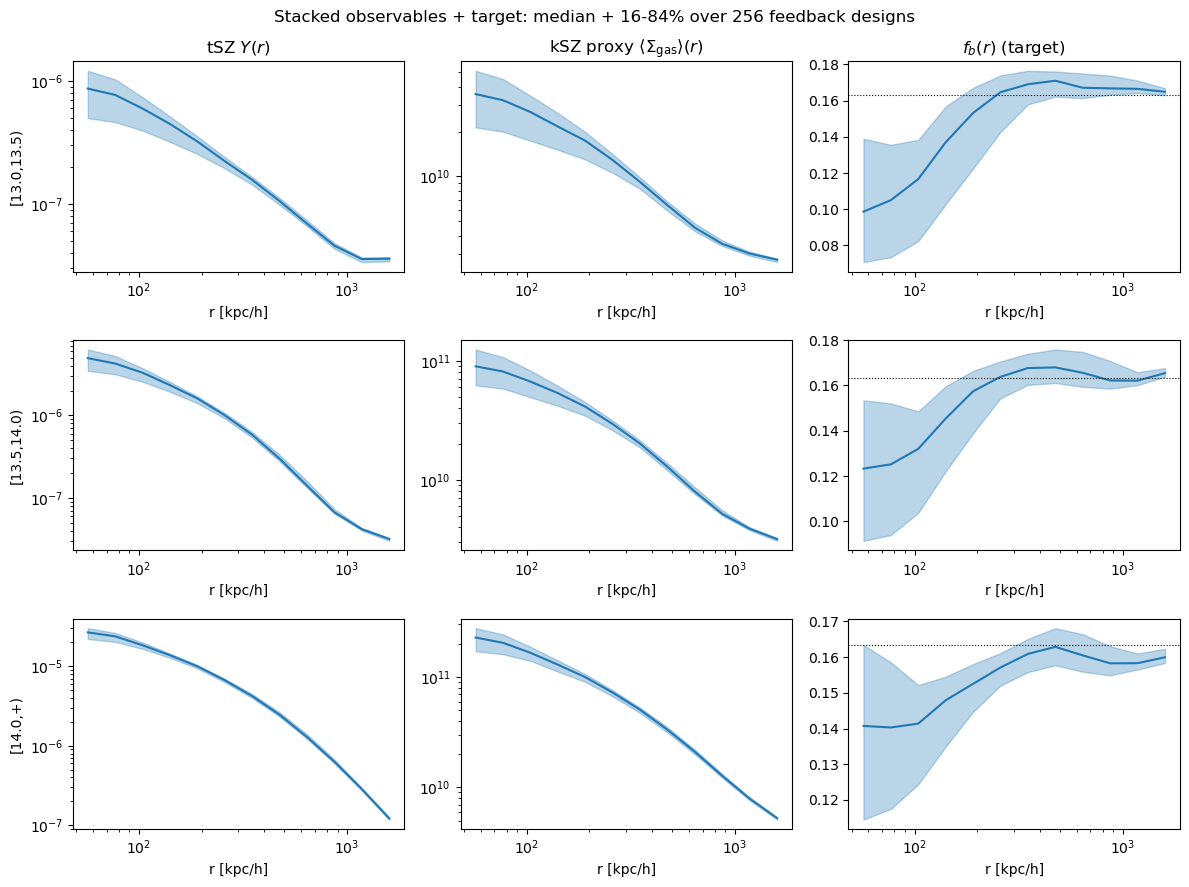

In [2]:
panels = [('Y', 'tSZ $Y(r)$', True), ('fb', '$f_b(r)$ (target)', False)]
if HAVE_KSZ:
    panels.insert(1, ('kSZ', 'kSZ proxy $\\langle\\Sigma_\\mathrm{gas}\\rangle(r)$', True))
fig, axes = plt.subplots(3, len(panels), figsize=(4*len(panels), 9))
for b, lbl in enumerate(MLBL):
    for j, (name, ttl, logy) in enumerate(panels):
        ax = axes[b, j]; P = Bp[name][:, b, :]
        med = np.nanmedian(P, 0); lo, hi = np.nanpercentile(P, [16, 84], 0)
        ax.plot(r, med, 'C0'); ax.fill_between(r, lo, hi, alpha=0.3, color='C0')
        ax.set_xscale('log'); ax.set_xlabel('r [kpc/h]')
        if logy: ax.set_yscale('log')
        if j == 0: ax.set_ylabel(lbl)
        if b == 0: ax.set_title(ttl)
        if name == 'fb': ax.axhline(0.049/0.30, ls=':', c='k', lw=0.8)
fig.suptitle('Stacked observables + target: median + 16-84% over 256 feedback designs')
fig.tight_layout(); fig.savefig(FIG/'stacks.png', dpi=130); print('saved stacks.png')
print('marginal std f_b(r) (×1e3) -- the spread to be explained:')
for b, lbl in enumerate(MLBL):
    print(f'  {lbl}:', (np.nanstd(Bp['fb'][:, b, :], 0)*1e3).round(2))

## 2. Held-out-design test (consistency in BIND-land)
Identical setup to `profile_fb_map.ipynb` §2: 5-fold CV over the 256 designs, joint
multi-output Ridge (α=10), log10 of decade-spanning observables, StandardScaler in/out.
Reduction(r) = `1 - σ(r)/σ_marg(r)`. Two ladders only: **Y** and **Y+kSZ**
(only Y if the cache is missing).

**Comparison to the previous notebook:** dropping S_X means the upper ladder is now
`Y+kSZ` instead of `Y+SX+T+S+P`. Whether kSZ adds on top of Y is the question. The
physical expectation is *yes for the outer profile* (Y ∝ nT integrates pressure;
kSZ ∝ n only) and *less for the core* where Y already saturates the gas information
via temperature.

mean held-out reduction in f_b(r) over radii:
ladder       [13.0,13.5)   [13.5,14.0)      [14.0,+)
Y                    69%           73%           67%
Y+kSZ                79%           79%           73%
saved reduction_vs_r.png


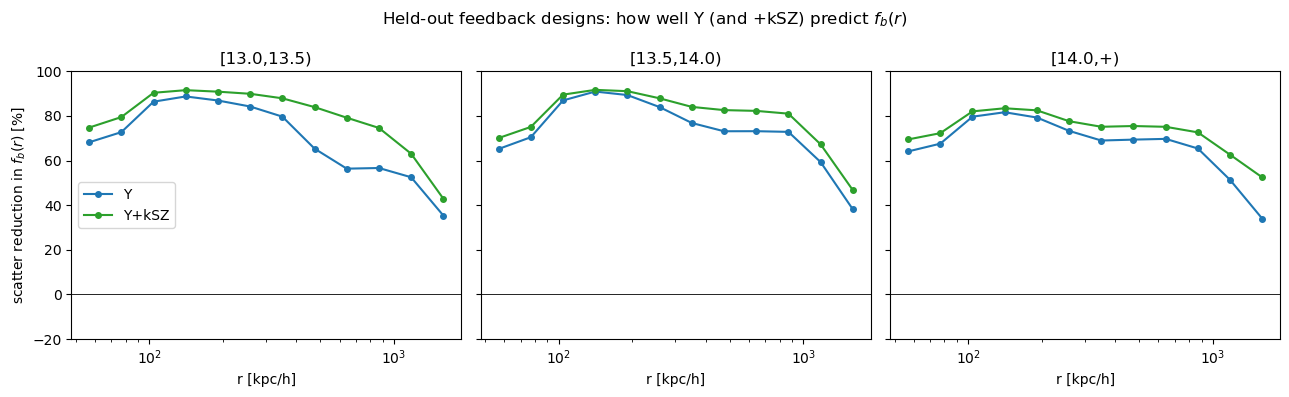

In [3]:
LADDERS = {'Y': ['Y']}
if HAVE_KSZ: LADDERS['Y+kSZ'] = ['Y', 'kSZ']
LOGFEAT = {'Y', 'kSZ'}

def feat(cols, b, src=Bp):
    out = []
    for c in cols:
        X = src[c][:, b, :].copy() if src[c].ndim == 3 else src[c][b, :][None, :].copy()
        if c in LOGFEAT: X = np.log10(np.clip(X, 1e-30, None))
        out.append(X)
    return np.hstack(out)

def oof_profile(X, Y_, alpha=10.0, seed=0):
    pred = np.full(Y_.shape, np.nan); kf = KFold(5, shuffle=True, random_state=seed)
    for tr, te in kf.split(X):
        xs = StandardScaler().fit(X[tr]); ys = StandardScaler().fit(Y_[tr])
        reg = Ridge(alpha=alpha).fit(xs.transform(X[tr]), ys.transform(Y_[tr]))
        pred[te] = ys.inverse_transform(reg.predict(xs.transform(X[te])))
    return pred

prof_res = {}
for b, lbl in enumerate(MLBL):
    Yt = Bp['fb'][:, b, :]; sig_marg = np.nanstd(Yt, 0)
    for L, cols in LADDERS.items():
        pred = oof_profile(feat(cols, b), Yt)
        sig = np.sqrt(np.nanmean((Yt - pred)**2, 0))
        prof_res[(L, lbl)] = dict(sig=sig, sig_marg=sig_marg, red=1-sig/sig_marg, pred=pred)

print('mean held-out reduction in f_b(r) over radii:')
print(f'{"ladder":10s}'+''.join(f'{l:>14s}' for l in MLBL))
for L in LADDERS:
    print(f'{L:10s}'+''.join(f'{np.nanmean(prof_res[(L,l)]["red"])*100:13.0f}%' for l in MLBL))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for b, lbl in enumerate(MLBL):
    ax = axes[b]
    for L, c in zip(LADDERS, ['C0', 'C2']):
        ax.plot(r, prof_res[(L, lbl)]['red']*100, 'o-', color=c, label=L, ms=4)
    ax.axhline(0, c='k', lw=0.6); ax.set_xscale('log')
    ax.set_xlabel('r [kpc/h]'); ax.set_title(lbl); ax.set_ylim(-20, 100)
axes[0].set_ylabel('scatter reduction in $f_b(r)$ [%]'); axes[0].legend()
fig.suptitle('Held-out feedback designs: how well Y (and +kSZ) predict $f_b(r)$')
fig.tight_layout(); fig.savefig(FIG/'reduction_vs_r.png', dpi=130); print('saved reduction_vs_r.png')

## 3. Truth on the BIND joint (does the relation transfer?)
Same idea as `profile_fb_realdata.ipynb` §2. Overlay the all-CV truth point at the
peak-information radius on the BIND `(log Y, f_b)` cloud. If truth lands on the BIND
conditional mean E[f_b | Y], the learned map transfers to hydro truth at the design centre.

saved truth_on_joint.png


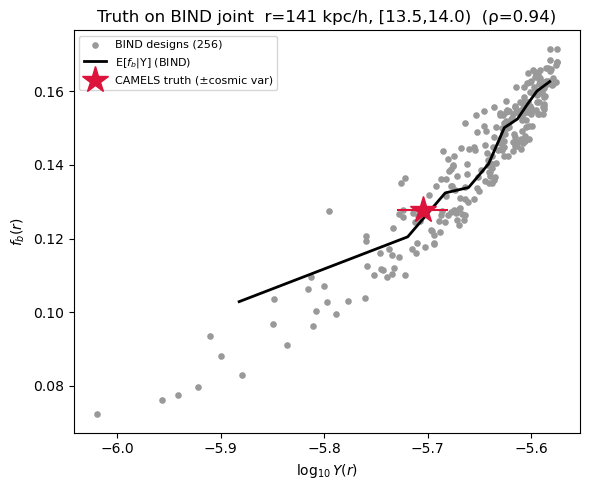

In [4]:
from scipy.stats import spearmanr
b = 1; lbl = MLBL[b]
ri = int(np.nanargmax(prof_res[('Y', lbl)]['red']))
x = np.log10(np.clip(Bp['Y'][:, b, ri], 1e-30, None)); y = Bp['fb'][:, b, ri]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, s=14, c='0.6', label='BIND designs (256)')
qe = np.quantile(x, np.linspace(0, 1, 11)); xc = 0.5*(qe[1:]+qe[:-1])
mu = [np.median(y[(x >= qe[k]) & (x <= qe[k+1])]) for k in range(10)]
ax.plot(xc, mu, 'k-', lw=2, label='E[$f_b$|Y] (BIND)')
tx = np.log10(truth['Y'][b, ri]); ty = truth['fb'][b, ri]
yb = band('fb')[:, b, ri]; xb = np.log10(band('Y')[:, b, ri])
ax.errorbar([tx], [ty], yerr=[[ty-yb[0]], [yb[1]-ty]], xerr=[[tx-xb[0]], [xb[1]-tx]],
            fmt='*', ms=20, c='crimson', label='CAMELS truth (±cosmic var)', zorder=5)
rho = spearmanr(x, y).statistic
ax.set_xlabel(r'$\log_{10}Y(r)$'); ax.set_ylabel('$f_b(r)$')
ax.set_title(f'Truth on BIND joint  r={r[ri]:.0f} kpc/h, {lbl}  (ρ={rho:.2f})')
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(FIG/'truth_on_joint.png', dpi=130); print('saved truth_on_joint.png')

## 4. Realistic forward model on the test observables

We apply three observational degradations to the **truth** profiles before feeding them
through the BIND-trained Ridge map. Each is a one-line operator on the radial profile;
they are **commutative** under our assumptions (axisymmetric profile, isotropic kernels).

### 4.1 Beam + miscentering as a single 2D Gaussian smoothing

**Beam.** A symmetric Gaussian PSF of FWHM `θ_b` smooths an axisymmetric image with
kernel std `σ_b = FWHM/(2√(2 ln 2))`.

**Miscentering.** If the assumed centre is offset from the true centre by a 2D vector
with each component independently `Normal(0, σ_cen)`, the radial offset s = |Δ| has a
Rayleigh(σ_cen) distribution. Stacking many such miscentred halos *is* a 2D Gaussian
convolution of the per-halo image by `Normal(0, σ_cen)` per axis. So beam and miscentering
**add in quadrature**: a single Gaussian of width `σ_total = √(σ_b² + σ_cen²)` does both.
We implement this by reconstructing a 2D image from the radial profile, Gaussian-filtering,
and re-azimuthally averaging — numerically cleaner than a Hankel transform for these few
annuli.

**Default kernel widths.** ACT/Planck angular FWHM ≈1.6′; at z≈0.1 the angular-diameter
distance ≈400 Mpc → 1′ ≈78 kpc/h, so 1.6′ ≈ 125 kpc/h FWHM → σ_b ≈53 kpc/h. Cluster
centroid scatter (BCG vs X-ray peak vs richness centroid) is typically `σ_cen ≈ 0.1–0.3·R_500c`,
i.e. ≈50–300 kpc/h for our mass range; default 150 kpc/h. **Both are larger than the
innermost annulus (≈57 kpc/h), so the inner reduction in §2 will collapse under realistic
obs — that is the headline of §5.**

### 4.2 Per-radius lognormal stack noise
Real stack S/N drops with radius: inner annuli are signal-dominated, outer are
background-dominated. We use multiplicative lognormal noise with std growing linearly
from `f_in` to `f_out` across the radial range, applied independently on Y and kSZ.
Default `f_in=5%`, `f_out=40%` — deliberately conservative; a real analysis would
import the per-bin stack covariance.

### 4.3 2-halo / projected-LSS additive offset
Y from a real CMB map integrates through the whole light cone. We approximate this as
a constant additive `Y_2h = η·Y_inner` blended in beyond `r_2h ≈ R_200(M)` via a
smoothstep. Default `η = 0`; turn on to see how a constant Y floor affects the outer
reduction. Not applied to kSZ — the velocity weighting makes the 2-halo contribution
of the pairwise kSZ signal small relative to tSZ.

In [5]:
# ---- helpers: realistic forward model on a 1D radial profile -------------------------
_GRID = 256
_xx, _yy = np.meshgrid(np.arange(_GRID)-_GRID/2+0.5, np.arange(_GRID)-_GRID/2+0.5)
_RR_PIX = np.sqrt(_xx**2 + _yy**2)
_RR_KPC = _RR_PIX * PIX_KPC_H

def _radial_to_2d(P, r_kpc):
    '''Linear-interp the radial profile P(r) onto the 2D grid; clamp ends.'''
    return np.interp(_RR_KPC.ravel(), r_kpc, P, left=P[0], right=P[-1]).reshape(_GRID, _GRID)

def _azim_avg(im, r_kpc):
    '''Re-azimuthally average a 2D image into the same r_kpc bins (geometric-mean centres).
    Empty annuli are filled by linear interpolation in log r against neighbouring bins.'''
    re = np.geomspace(r_kpc[0]/np.sqrt(r_kpc[1]/r_kpc[0]),
                       r_kpc[-1]*np.sqrt(r_kpc[-1]/r_kpc[-2]), len(r_kpc)+1)
    out = np.full(len(r_kpc), np.nan); flat = im.ravel(); rr = _RR_KPC.ravel()
    for i in range(len(r_kpc)):
        m = (rr >= re[i]) & (rr < re[i+1])
        if m.any(): out[i] = flat[m].mean()
    if np.isnan(out).any():            # patch empties with neighbour interp in log r
        good = ~np.isnan(out)
        if good.sum() >= 2:
            out[~good] = np.interp(np.log(r_kpc[~good]),
                                   np.log(r_kpc[good]), out[good])
    return out

def smooth_profile(P, r_kpc, sigma_kpc):
    '''Apply a 2D Gaussian smoothing of width sigma_kpc to an axisymmetric profile.'''
    if sigma_kpc <= 0: return P.copy()
    im = _radial_to_2d(P, r_kpc)
    im_s = gaussian_filter(im, sigma=sigma_kpc/PIX_KPC_H, mode='nearest')
    return _azim_avg(im_s, r_kpc)

def lognormal_noise(P, r_kpc, f_in=0.05, f_out=0.40, rng=None):
    rng = rng or np.random.default_rng()
    t = (np.log(r_kpc) - np.log(r_kpc[0])) / (np.log(r_kpc[-1]) - np.log(r_kpc[0]))
    sig = f_in + (f_out - f_in) * t
    return P * np.exp(rng.normal(0, sig))

def two_halo(P, r_kpc, eta=0.0, r_2h=800.0):
    if eta == 0.0: return P
    s = 1.0/(1.0 + np.exp(-(r_kpc - r_2h)/(0.3*r_2h)))   # smoothstep around r_2h
    return P + eta * P[0] * s

def forward_model(profiles, r_kpc, sigma_kpc, f_in=0.05, f_out=0.40, eta=0.0, rng=None):
    '''Apply beam+miscentering, lognormal noise (Y and kSZ), and 2-halo offset (Y only).'''
    out = {}
    for k, P in profiles.items():                    # P is (3, nr)
        Pk = np.array([smooth_profile(P[b], r_kpc, sigma_kpc) for b in range(P.shape[0])])
        if k == 'Y':  Pk = np.array([two_halo(Pk[b], r_kpc, eta) for b in range(Pk.shape[0])])
        if k in ('Y', 'kSZ') and (f_in > 0 or f_out > 0):
            Pk = np.array([lognormal_noise(Pk[b], r_kpc, f_in, f_out, rng) for b in range(Pk.shape[0])])
        out[k] = Pk
    return out

# sanity: smoothing a flat profile is invariant; smoothing a delta-like inner core
test = np.zeros(nr); test[0] = 1.0
print('beam check  σ=0   :', smooth_profile(test, r, 0).round(3))
print('beam check  σ=150 :', smooth_profile(test, r, 150).round(3))


beam check  σ=0   : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
beam check  σ=150 : [0.058 0.058 0.052 0.045 0.029 0.015 0.005 0.001 0.    0.    0.    0.   ]


## 5. Predict truth f_b(r) from forward-modelled truth observables
Train the Ridge map on **all 256 BIND clean designs** (no fold needed since the test
is the all-CV truth), then feed the truth profiles after applying the forward model.
We sweep three regimes:

- **Clean** (§3 of `profile_fb_realdata`): no beam, no miscentering, no noise. Reference.
- **Realistic 1′** (Planck-like, deep stack): σ_total ≈ √(53²+150²) ≈ 159 kpc/h, 5→20% noise.
- **Realistic 1.6′** (default ACT): σ_total ≈ √(85²+150²) ≈ 172 kpc/h, 5→40% noise.

We Monte-Carlo the noise realisations (200 draws) and plot the prediction band against
the truth + cosmic-variance band. The miscentering and beam are **deterministic** for
a stack at fixed widths; only the noise is stochastic.

saved pred_vs_truth_realistic.png


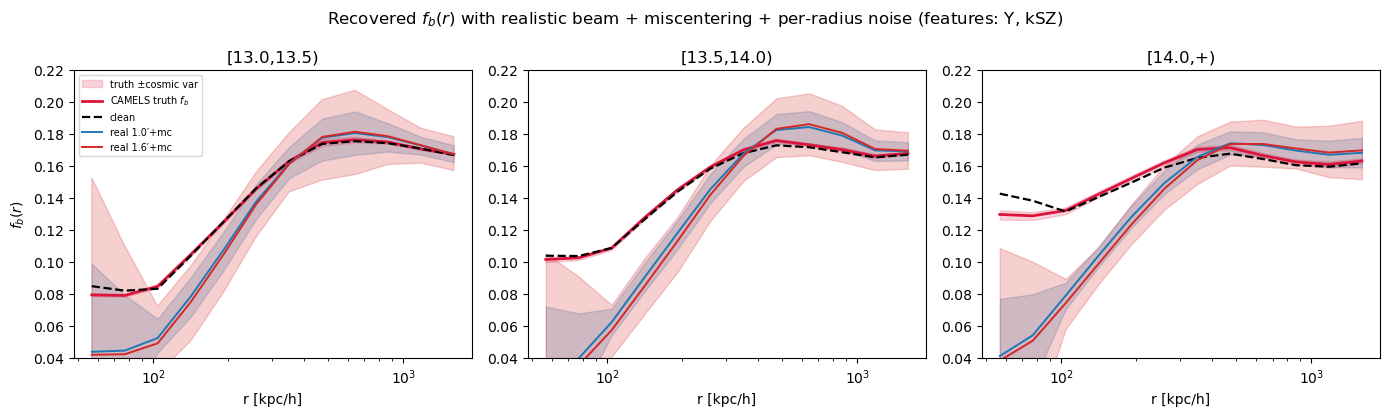

In [6]:
OBS_COLS = ['Y'] + (['kSZ'] if HAVE_KSZ else [])

def train_ridge(b, alpha=10.0):
    Xtr = feat(OBS_COLS, b); Ytr = Bp['fb'][:, b, :]
    xs = StandardScaler().fit(Xtr); ys = StandardScaler().fit(Ytr)
    reg = Ridge(alpha=alpha).fit(xs.transform(Xtr), ys.transform(Ytr))
    return xs, ys, reg

def predict_fb(b, obs):
    xs, ys, reg = train_ridge(b)
    cols = []
    for c in OBS_COLS:
        v = obs[c][b]; v = np.log10(np.clip(v, 1e-30, None)) if c in LOGFEAT else v
        cols.append(v[None, :])
    X = xs.transform(np.hstack(cols))
    # any NaN bin (e.g. an empty annulus after 2D smoothing+re-azim-avg) -> column mean
    X = np.nan_to_num(X, nan=0.0)
    return ys.inverse_transform(reg.predict(X))[0]

REGIMES = [
    dict(name='clean',         sigma=0.0,   f_in=0.0,  f_out=0.0,  eta=0.0),
    dict(name='real 1.0′+mc',  sigma=159.0, f_in=0.05, f_out=0.20, eta=0.0),
    dict(name='real 1.6′+mc',  sigma=172.0, f_in=0.05, f_out=0.40, eta=0.0),
]
REG_COLORS = {'clean': 'k', 'real 1.0′+mc': 'C0', 'real 1.6′+mc': 'C3'}
nmc = 200
results = {}
fig, axes = plt.subplots(1, len(MLBL), figsize=(14, 4.2))
for b, (ax, lbl) in enumerate(zip(axes, MLBL)):
    tb = band('fb')[:, b, :]
    ax.fill_between(r, tb[0], tb[1], color='crimson', alpha=0.18, label='truth ±cosmic var')
    ax.plot(r, truth['fb'][b], '-', c='crimson', lw=2.0, label='CAMELS truth $f_b$')
    for reg in REGIMES:
        c = REG_COLORS[reg['name']]
        # deterministic part: smooth+two_halo, applied once
        prof_obs = {k: truth[k].copy() for k in OBS_COLS}
        prof_det = forward_model(prof_obs, r, reg['sigma'], 0.0, 0.0, reg['eta'])
        if reg['f_out'] == 0:
            p = predict_fb(b, prof_det)
            ax.plot(r, p, '--', c=c, lw=1.6, label=f"{reg['name']}")
            results[(reg['name'], lbl)] = dict(mean=p, lo=p, hi=p)
        else:
            draws = np.array([predict_fb(b, forward_model(prof_det, r, 0.0,
                                                         reg['f_in'], reg['f_out'], 0.0,
                                                         np.random.default_rng(s)))
                              for s in range(nmc)])
            lo, hi = np.percentile(draws, [16, 84], 0); mean = draws.mean(0)
            ax.plot(r, mean, '-', c=c, lw=1.4, label=f"{reg['name']}")
            ax.fill_between(r, lo, hi, color=c, alpha=0.22)
            results[(reg['name'], lbl)] = dict(mean=mean, lo=lo, hi=hi)
    ax.set_xscale('log'); ax.set_xlabel('r [kpc/h]'); ax.set_title(lbl)
    ax.set_ylim(0.04, 0.22)
axes[0].set_ylabel('$f_b(r)$'); axes[0].legend(fontsize=7)
fig.suptitle('Recovered $f_b(r)$ with realistic beam + miscentering + per-radius noise '
             f"(features: {', '.join(OBS_COLS)})")
fig.tight_layout(); fig.savefig(FIG/'pred_vs_truth_realistic.png', dpi=130)
print('saved pred_vs_truth_realistic.png')


## 5.1 Headline numbers
RMS|pred − truth| in `f_b` per regime per mass bin (×1e3). Compare against:
- truth f_b range ≈ 0.08–0.18
- BIND feedback scatter `σ_marg(r)` ≈ 0.02–0.03 (i.e. 20–30 in these units)
- CV cosmic-variance band ≈ 5–10 in these units

If the realistic-regime RMS approaches `σ_marg`, the realistic forward model has
erased the feedback information — the practical S/N requirement for a real measurement
to learn anything past the cosmic mean.

In [7]:
print(f'{"regime":18s}'+''.join(f'{l:>16s}' for l in MLBL))
summary = {}
for reg in REGIMES:
    row = f"{reg['name']:18s}"
    summary[reg['name']] = {}
    for b, lbl in enumerate(MLBL):
        m = results[(reg['name'], lbl)]['mean']
        rms = np.sqrt(np.nanmean((m - truth['fb'][b])**2))
        summary[reg['name']][lbl] = float(rms)
        row += f'{rms*1e3:15.2f} '
    print(row)

regime                 [13.0,13.5)     [13.5,14.0)        [14.0,+)
clean                        1.92            1.58            5.25 
real 1.0′+mc                19.60           33.78           39.43 
real 1.6′+mc                21.38           36.86           41.91 


## 6. Save machine-readable results

In [8]:
import json
out = {
    'r_kpc': r.tolist(), 'mass_bins': MLBL, 'observables': OBS_COLS,
    'have_kSZ_cache': bool(HAVE_KSZ),
    'pixel_scale_kpc_h': float(PIX_KPC_H),
    'design_reduction': {
        f'{L}|{lbl}': dict(
            mean_reduction=float(np.nanmean(prof_res[(L, lbl)]['red'])),
            reduction_vs_r=[float(x) for x in prof_res[(L, lbl)]['red']],
            sig_vs_r=[float(x) for x in prof_res[(L, lbl)]['sig']],
            sig_marg_vs_r=[float(x) for x in prof_res[(L, lbl)]['sig_marg']])
        for L in LADDERS for lbl in MLBL},
    'regimes': REGIMES,
    'rms_pred_minus_truth': summary,
    'truth_fb': {l: truth['fb'][b].tolist() for b, l in enumerate(MLBL)},
    'pred_per_regime': {f'{n}|{l}': dict(mean=results[(n, l)]['mean'].tolist(),
                                         lo=results[(n, l)]['lo'].tolist(),
                                         hi=results[(n, l)]['hi'].tolist())
                        for n in [reg['name'] for reg in REGIMES] for l in MLBL},
}
json.dump(out, open(FIG/'ysz_ksz_results.json', 'w'), indent=2)
print('wrote', FIG/'ysz_ksz_results.json')

wrote figures/observable_fb_ysz_ksz/ysz_ksz_results.json


## 7. Threats to validity (this notebook only)
1. **Forward model on the test side only.** A consistent treatment beams the BIND
   training profiles too. We chose to keep training clean to isolate *how much
   information the instrument removes* from a noise-free map; this is an *upper
   bound* on what beam-aware retraining could recover.
2. **kSZ proxy = ⟨Σ_gas⟩.** Correct shape; amplitude conversion via `σ_T (v/c)/μ_e m_p`
   drops out of feature scaling but the noise model in real kSZ stacks is *not* a flat
   lognormal — pairwise estimators have specific covariance structure (correlated across
   redshift bins, anisotropic from velocity reconstruction). Treat as indicative.
3. **Single 2D Gaussian beam+miscentering.** Real PSFs have non-Gaussian wings (Airy,
   matched-filter sidelobes); real miscentering is bimodal (well-centred + tail). Both
   are conservative simplifications that **understate** the inner-radius information loss.
4. **2-halo blanked off.** A flat outer offset is the simplest possible nuisance; the
   full HM 2-halo term is mass-dependent and correlated with the 1-halo amplitude.
5. **All other caveats from `profile_fb_map.ipynb`/`profile_fb_realdata.ipynb` apply unchanged.**